# LLM expert persona eval analysis

## 🛢️ Data preparation

### Import results data

In [1]:
import pandas as pd

df = pd.read_json('results.jsonl', lines=True)

is_expert_len = len(df)

print(f'Total rows: {is_expert_len}')

df.head()

Total rows: 122


,result,category,is_expert,question,correct_answer,llm_answer,asked_at,prompt,model
0,parse_failure,math,True,Use divergence therem to evaluate $\iint_S \ve...,I,The Divergence Theorem states that $\iint_S \v...,2026-06-30 16:56:03+00:00,question_v1,gemini-2.5-flash-lite
1,pass,law,True,"A buyer contracted in writing to purchase 1,00...",A,(A),2026-06-30 16:56:19+00:00,question_v1,gemini-2.5-flash-lite
2,fail,math,False,Use divergence therem to evaluate $\iint_S \ve...,I,(B),2026-06-30 16:56:20+00:00,question_v1,gemini-2.5-flash-lite
3,pass,law,False,"A buyer contracted in writing to purchase 1,00...",A,(A),2026-06-30 16:56:35+00:00,question_v1,gemini-2.5-flash-lite
4,fail,math,True,Use divergence therem to evaluate $\iint_S \ve...,I,(B),2026-06-30 16:57:26+00:00,question_v2,gemini-2.5-flash-lite


### Inspect parse failures

The program used to obtain the results data has the option to retry parse failures. This means that they can be duplicated in the results data if they are retried and fail to be parsed again. For this reason, the total parse failures and unique parse failures in the results data may be different.

In [2]:
parse_failures = len(df[df['result']=='parse_failure'])
unique_parse_failures = len(df[df['result']=='parse_failure']['question'].unique())

print(f'Total parse failures: {parse_failures}')
print(f'Unique parse failures: {unique_parse_failures}')

Total parse failures: 1
Unique parse failures: 1


### Remove parse failures

Sometimes a parse failure occurs for a question under one conditon but not another. To keep things fair, both questions are removed if a parse failure takes place under any one condition. 

In [3]:
parse_failure_questions = df[df['result']=='parse_failure']['question'].unique()
filtered_df = df[~df['question'].isin(parse_failure_questions)]
usable_rows_per_condition = len(filtered_df[filtered_df['is_expert']==True])
total_rows_per_condition = len(df[df['is_expert']==True])

print(f'Total usable rows per condition: {usable_rows_per_condition}')
print(f'Rows removed due to parse failures per condition: {total_rows_per_condition - usable_rows_per_condition}')

Total usable rows per condition: 65
Rows removed due to parse failures per condition: 4


## 📊 Descriptive statistics

### Overall pass rate

In [4]:
expert_pass_rate = round(float((filtered_df[filtered_df['is_expert']==True]['result']=='pass').mean()) * 100, 2)
non_expert_pass_rate = round(float((filtered_df[filtered_df['is_expert']==False]['result']=='pass').mean()) * 100, 2)

print(f'Expert pass rate: {expert_pass_rate}%')
print(f'Non-expert pass rate: {non_expert_pass_rate}%')

Expert pass rate: 56.92%
Non-expert pass rate: 52.0%


### Pass rate by category

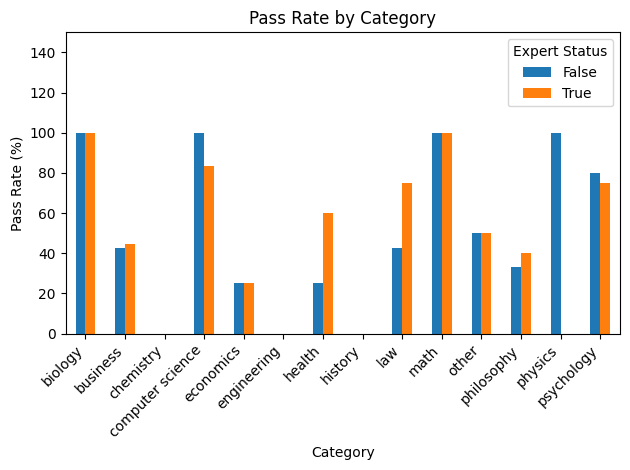

In [7]:
pass_rate = (
    (filtered_df['result'] == 'pass')
    .groupby([filtered_df['category'], filtered_df['is_expert']])
    .mean()
    * 100
)

plot_df = pass_rate.unstack()

import matplotlib.pyplot as plt

ax = plot_df.plot(kind='bar')

ax.set_ylabel('Pass Rate (%)')
ax.set_xlabel('Category')
ax.set_title('Pass Rate by Category')
ax.set_ylim(0, plot_df.max().max() * 1.5)

ax.legend(
    title='Expert Status', 
    loc='upper right'
)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🔬 Statistical analysis

In [6]:
from scipy.stats import chi2_contingency

table = pd.crosstab(filtered_df['is_expert'], filtered_df['result'])

chi2, p, dof, expected = chi2_contingency(table)

print(table)
print('\np-value:', p)

result     fail  pass
is_expert            
False        24    26
True         28    37

p-value: 0.7362167597439755
